<a href="https://colab.research.google.com/github/kbook6/tamu-engy644/blob/main/ssw_engy644finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENGY 644 Final Project - Two-Stage Stochastic Renewable Procurement Model for a College Station Microgrid (Python Version)
## Group Members: Katherine Book and Shelley Smith Woods
May 2026

In [ ]:
# notes
# pyomo website: https://www.pyomo.org/

In [ ]:
# Set-up code environment
# Check for Colab

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !apt-get install -y glpk-utils
    !pip install pyomo
    from google.colab import drive
    drive.mount('/content/drive')


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
glpk-utils is already the newest version (5.0-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries

!apt-get install -y glpk-utils
!pip install pyomo pandas numpy
import pyomo.environ as pyo
from pyomo.environ import Constraint, Objective
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
glpk-utils is already the newest version (5.0-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


## Loading Data Files

In [ ]:
# Import data files
# Set and define file path for data files

econ_file_path = '/content/drive/My Drive/644 Final Project/Datafiles/Hourly_Economic_Data.csv'
demand_file_path = '/content/drive/My Drive/644 Final Project/Datafiles/Demand_MWh_By_Scenario.csv'
wind_file_path = '/content/drive/My Drive/644 Final Project/Datafiles/Wind_CF_By_Scenario.csv'
solar_file_path = '/content/drive/My Drive/644 Final Project/Datafiles/Solar_CF_By_Scenario.csv'
stats_file_path = '/content/drive/My Drive/644 Final Project/Datafiles/Quick_Stats.csv'


In [ ]:
# Load and review data files

def load_csv(file_path, label):
    try:
        print(f"\n Loading: {label}")
        df = pd.read_csv(file_path)
        print(f"Loaded successfully | Shape: {df.shape}")
        display(df.head())
        return df
    except FileNotFoundError:
        print(f"File not found at: {file_path}")
        return None

df_econ = load_csv(econ_file_path, "Hourly Economic Data")
df_demand = load_csv(demand_file_path, "Demand MWh by Scenario")
df_wind = load_csv(wind_file_path, "Wind CF by Scenario")
df_solar = load_csv(solar_file_path, "Solar CF by Scenario")
df_stats = load_csv(stats_file_path, "Quick Stats")


 Loading: Hourly Economic Data
Loaded successfully | Shape: (24, 10)


,Hour,Base_Load_MWh,Grid_Buy_Price_$_per_MWh,Export_Price_$_per_MWh,Solar_Contract_Cost_$_per_MW_block,Wind_Contract_Cost_$_per_MW_block,Solar_Max_Blocks_MW,Wind_Max_Blocks_MW,Base_Solar_CF,Base_Wind_CF
0,1,8.4,28,6,8,10,20,14,0.0,0.44
1,2,8.1,27,6,8,10,20,14,0.0,0.46
2,3,7.9,26,6,8,10,20,14,0.0,0.47
3,4,7.8,25,6,8,10,20,14,0.0,0.48
4,5,7.9,25,6,8,10,20,14,0.0,0.46



 Loading: Demand MWh by Scenario
Loaded successfully | Shape: (24, 9)


,Hour,Hot_Clear,Hot_Hazy,Hot_Cloudy,Storm_PM,Clear_Breezy,Mild_Balanced,Overcast_Windy,Cloudy_Calm
0,1,8.90,9.07,8.99,8.65,8.23,7.90,7.82,8.4
1,2,8.59,8.75,8.67,8.34,7.94,7.62,7.54,8.1
2,3,8.37,8.53,8.45,8.14,7.74,7.43,7.35,7.9
3,4,8.27,8.42,8.35,8.03,7.64,7.34,7.26,7.8
4,5,8.37,8.53,8.45,8.14,7.74,7.43,7.35,7.9



 Loading: Wind CF by Scenario
Loaded successfully | Shape: (24, 9)


,Hour,Hot_Clear,Hot_Hazy,Hot_Cloudy,Storm_PM,Clear_Breezy,Mild_Balanced,Overcast_Windy,Cloudy_Calm
0,1,0.44,0.317,0.462,0.418,0.537,0.44,0.638,0.264
1,2,0.46,0.331,0.483,0.437,0.561,0.46,0.653,0.276
2,3,0.47,0.343,0.494,0.446,0.564,0.47,0.658,0.282
3,4,0.48,0.355,0.504,0.456,0.566,0.48,0.662,0.288
4,5,0.46,0.340,0.478,0.437,0.529,0.46,0.621,0.285



 Loading: Solar CF by Scenario
Loaded successfully | Shape: (24, 9)


,Hour,Hot_Clear,Hot_Hazy,Hot_Cloudy,Storm_PM,Clear_Breezy,Mild_Balanced,Overcast_Windy,Cloudy_Calm
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



 Loading: Quick Stats
Loaded successfully | Shape: (6, 2)


,Metric,Value
0,Average base load (MW),12.51
1,Peak base load (MW),17.20
2,Average grid buy price ($/MWh),59.79
3,Peak grid buy price ($/MWh),116.00
4,Daily solar energy per 1 MW contracted on clea...,6.85


In [ ]:
# Define model structure
# Defines the 24 hourly periods, weather scenarios, and the probability for
#each scenario

T = list(df_econ["Hour"])

scenarios = [
    "Hot_Clear",
    "Hot_Hazy",
    "Hot_Cloudy",
    "Storm_PM",
    "Clear_Breezy",
    "Mild_Balanced",
    "Overcast_Windy",
    "Cloudy_Calm"
]

prob = {
    "Hot_Clear": 0.16,
    "Hot_Hazy": 0.14,
    "Hot_Cloudy": 0.12,
    "Storm_PM": 0.10,
    "Clear_Breezy": 0.14,
    "Mild_Balanced": 0.14,
    "Overcast_Windy": 0.10,
    "Cloudy_Calm": 0.10
}

print("Hours:", T[:5], "...", T[-5:])
print("Scenarios:", scenarios)
print("Probability sum:", sum(prob.values()))

Hours: [1, 2, 3, 4, 5] ... [20, 21, 22, 23, 24]
Scenarios: ['Hot_Clear', 'Hot_Hazy', 'Hot_Cloudy', 'Storm_PM', 'Clear_Breezy', 'Mild_Balanced', 'Overcast_Windy', 'Cloudy_Calm']
Probability sum: 1.0


In [ ]:
# Economic parameters
# Conversion of hourly economic data for Pyomo to read

grid_price = dict(zip(df_econ["Hour"], df_econ["Grid_Buy_Price_$_per_MWh"]))
export_price = dict(zip(df_econ["Hour"], df_econ["Export_Price_$_per_MWh"]))

solar_cost = dict(zip(df_econ["Hour"], df_econ["Solar_Contract_Cost_$_per_MW_block"]))
wind_cost = dict(zip(df_econ["Hour"], df_econ["Wind_Contract_Cost_$_per_MW_block"]))

solar_cap = dict(zip(df_econ["Hour"], df_econ["Solar_Max_Blocks_MW"]))
wind_cap = dict(zip(df_econ["Hour"], df_econ["Wind_Max_Blocks_MW"]))


In [ ]:
# Scenario Conversion
# Conversion of demand, solar and wind capacity factors into (hour, scenario)
# for Pyomo

D = {}
qS = {}
qW = {}

for _, row in df_demand.iterrows():
    t = row["Hour"]
    for w in scenarios:
        D[(t, w)] = row[w]

for _, row in df_solar.iterrows():
    t = row["Hour"]
    for w in scenarios:
        qS[(t, w)] = row[w]

for _, row in df_wind.iterrows():
    t = row["Hour"]
    for w in scenarios:
        qW[(t, w)] = row[w]

## Build Base Stochastic Model (SP)

In [ ]:
# Initialize model
# Creates the Pyomo model container and attaches all variables, constraints, and
# objectives.

m = pyo.ConcreteModel()

In [ ]:
# Load data into model
# Load sets and parameters (hours, scenarios, probabilities, demand, renewable
# availability, prices, and capacity limits)

m.T = pyo.Set(initialize=T)
m.Omega = pyo.Set(initialize=scenarios)

m.prob = pyo.Param(m.Omega, initialize=prob)

m.D = pyo.Param(m.T, m.Omega, initialize=D)
m.qS = pyo.Param(m.T, m.Omega, initialize=qS)
m.qW = pyo.Param(m.T, m.Omega, initialize=qW)

m.cS = pyo.Param(m.T, initialize=solar_cost)
m.cW = pyo.Param(m.T, initialize=wind_cost)

m.pG = pyo.Param(m.T, initialize=grid_price)
m.pE = pyo.Param(m.T, initialize=export_price)

m.US = pyo.Param(m.T, initialize=solar_cap)
m.UW = pyo.Param(m.T, initialize=wind_cap)

print("Loaded successfully.")

Loaded successfully.


In [ ]:
# Define decision variables
# First-stage variables: solar and wind commitments pre-weather
# Second-stage vriables: grid purchases and exports post-weather

# First-stage variables
m.xS = pyo.Var(m.T, domain=pyo.NonNegativeReals)
m.xW = pyo.Var(m.T, domain=pyo.NonNegativeReals)

# Second-stage variables
m.g = pyo.Var(m.T, m.Omega, domain=pyo.NonNegativeReals)
m.e = pyo.Var(m.T, m.Omega, domain=pyo.NonNegativeReals)

print("Loaded successfully.")

Loaded successfully.


In [ ]:
# Objective Function
# Minimize total cost: day-ahead renewable contracts, expected grid purchase
# costs, minus export revenue

def objective_rule(m):
    first_stage_cost = sum(
        m.cS[t] * m.xS[t] + m.cW[t] * m.xW[t]
        for t in m.T
    )

    expected_recourse_cost = sum(
        m.prob[w] * sum(
            m.pG[t] * m.g[t, w] - m.pE[t] * m.e[t, w]
            for t in m.T
        )
        for w in m.Omega
    )

    return first_stage_cost + expected_recourse_cost

m.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

print("Loaded successfully.")

Loaded successfully.


In [ ]:
# Constraints
# Energy balance constraint and capacity limits

def energy_balance_rule(m, t, w):
    return (
        m.qS[t, w] * m.xS[t]
        + m.qW[t, w] * m.xW[t]
        + m.g[t, w]
        - m.e[t, w]
        == m.D[t, w]
    )

m.energy_balance = pyo.Constraint(m.T, m.Omega, rule=energy_balance_rule)


def solar_capacity_rule(m, t):
    return m.xS[t] <= m.US[t]

m.solar_capacity = pyo.Constraint(m.T, rule=solar_capacity_rule)


def wind_capacity_rule(m, t):
    return m.xW[t] <= m.UW[t]

m.wind_capacity = pyo.Constraint(m.T, rule=wind_capacity_rule)

print("Loaded successfully.")

Loaded successfully.


## Solve Stochastic Model

In [ ]:
# Solve the model to get the optimal value from the solver

solver = pyo.SolverFactory("glpk")
results = solver.solve(m, tee=True)

print("Solver Status:", results.solver.status)
print("Termination Condition:", results.solver.termination_condition)
print("Stochastic Program Objective Value:", pyo.value(m.objective))


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmp49d4qca4.glpk.raw --wglp /tmp/tmpm_p3cvje.glpk.glp --cpxlp
 /tmp/tmp1anxlzx3.pyomo.lp
Reading problem data from '/tmp/tmp1anxlzx3.pyomo.lp'...
240 rows, 432 columns, 736 non-zeros
2329 lines were read
Writing problem data to '/tmp/tmpm_p3cvje.glpk.glp'...
2083 lines were written
GLPK Simplex Optimizer 5.0
240 rows, 432 columns, 736 non-zeros
Preprocessing...
31 rows, 51 columns, 85 non-zeros
Scaling...
 A: min|aij| =  1.480e-01  max|aij| =  1.000e+00  ratio =  6.757e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 31
*     0: obj =   1.711226624e+04 inf =   0.000e+00 (20)
*    36: obj =   1.202252240e+04 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.3 Mb (338312 bytes)
Writing basic solution to '/tmp/tmp49d4qca4.glpk.raw'...
681 lines were written
Solver Status: ok
Termination Condition: optimal
Stochastic Pro

In [ ]:
# Quick optimality check ***DELETE LATER***
print("Solver Status:", results.solver.status)
print("Termination Condition:", results.solver.termination_condition)

Solver Status: ok
Termination Condition: optimal


In [ ]:
# First Stage Results
# Energy committments before weather considerations

sp_commitments = pd.DataFrame({
    "Hour": T,
    "Solar_xS": [pyo.value(m.xS[t]) for t in T],
    "Wind_xW": [pyo.value(m.xW[t]) for t in T]
})

display(sp_commitments)

,Hour,Solar_xS,Wind_xW
0,1,0.0,14.000000
1,2,0.0,14.000000
2,3,0.0,13.723404
3,4,0.0,13.498233
4,5,0.0,14.000000
5,6,0.0,14.000000
6,7,0.0,14.000000
7,8,0.0,14.000000
8,9,20.0,14.000000
9,10,20.0,13.040000


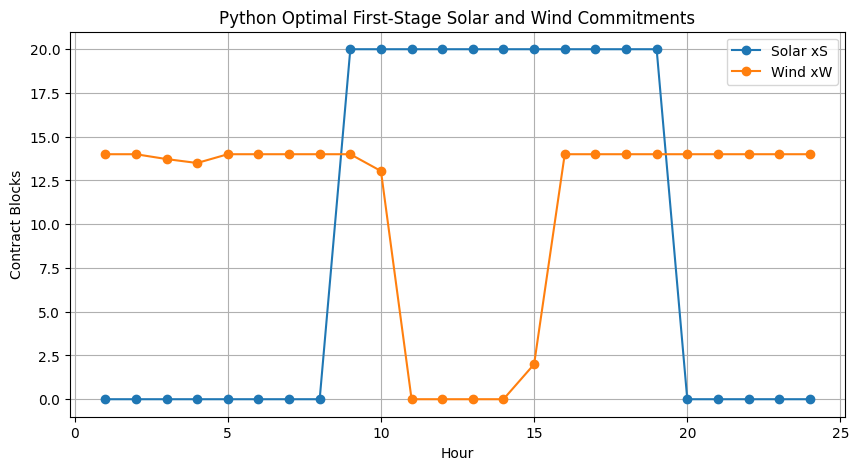

In [ ]:
# First Stage Plot
# Visualiztion of energy commitments in 24 hrs

plt.figure(figsize=(10, 5))

plt.plot(sp_commitments["Hour"], sp_commitments["Solar_xS"], marker="o", label="Solar xS")
plt.plot(sp_commitments["Hour"], sp_commitments["Wind_xW"], marker="o", label="Wind xW")

plt.xlabel("Hour")
plt.ylabel("Contract Blocks")
plt.title("Python Optimal First-Stage Solar and Wind Commitments")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Second Stage Results

recourse_results = []

for w in scenarios:
    for t in T:
        recourse_results.append({
            "Scenario": w,
            "Hour": t,
            "Grid_Purchase_g": pyo.value(m.g[t, w]),
            "Export_e": pyo.value(m.e[t, w])
        })

sp_recourse = pd.DataFrame(recourse_results)

display(sp_recourse.head(20))

,Scenario,Hour,Grid_Purchase_g,Export_e
0,Hot_Clear,1,2.740000,0.00
1,Hot_Clear,2,2.150000,0.00
2,Hot_Clear,3,1.920000,0.00
3,Hot_Clear,4,1.790848,0.00
4,Hot_Clear,5,1.930000,0.00
5,Hot_Clear,6,3.020000,0.00
6,Hot_Clear,7,4.890000,0.00
7,Hot_Clear,8,7.080000,0.00
8,Hot_Clear,9,4.020000,0.00
9,Hot_Clear,10,1.710400,0.00


In [ ]:
# Scenario Cost Summary

scenario_costs = []

first_stage_cost_value = sum(
    solar_cost[t] * pyo.value(m.xS[t]) + wind_cost[t] * pyo.value(m.xW[t])
    for t in T
)

for w in scenarios:
    recourse_cost = sum(
        grid_price[t] * pyo.value(m.g[t, w]) - export_price[t] * pyo.value(m.e[t, w])
        for t in T
    )

    total_cost = first_stage_cost_value + recourse_cost

    scenario_costs.append({
        "Scenario": w,
        "Probability": prob[w],
        "First_Stage_Cost": first_stage_cost_value,
        "Recourse_Cost": recourse_cost,
        "Total_Cost": total_cost,
        "Weighted_Total_Cost": prob[w] * total_cost
    })

sp_cost_summary = pd.DataFrame(scenario_costs)

display(sp_cost_summary)

print("First-stage cost:", first_stage_cost_value)
print("Expected stochastic objective:", sp_cost_summary["Weighted_Total_Cost"].sum())



,Scenario,Probability,First_Stage_Cost,Recourse_Cost,Total_Cost,Weighted_Total_Cost
0,Hot_Clear,0.16,4422.616375,6972.580401,11395.196776,1823.231484
1,Hot_Hazy,0.14,4422.616375,9583.078821,14005.695196,1960.797327
2,Hot_Cloudy,0.12,4422.616375,10278.226057,14700.842432,1764.101092
3,Storm_PM,0.10,4422.616375,9182.771866,13605.388240,1360.538824
4,Clear_Breezy,0.14,4422.616375,4066.134000,8488.750375,1188.425052
5,Mild_Balanced,0.14,4422.616375,4481.668241,8904.284616,1246.599846
6,Overcast_Windy,0.10,4422.616375,6989.866458,11412.482832,1141.248283
7,Cloudy_Calm,0.10,4422.616375,10953.188561,15375.804936,1537.580494


First-stage cost: 4422.6163747086675
Expected stochastic objective: 12022.522402960378


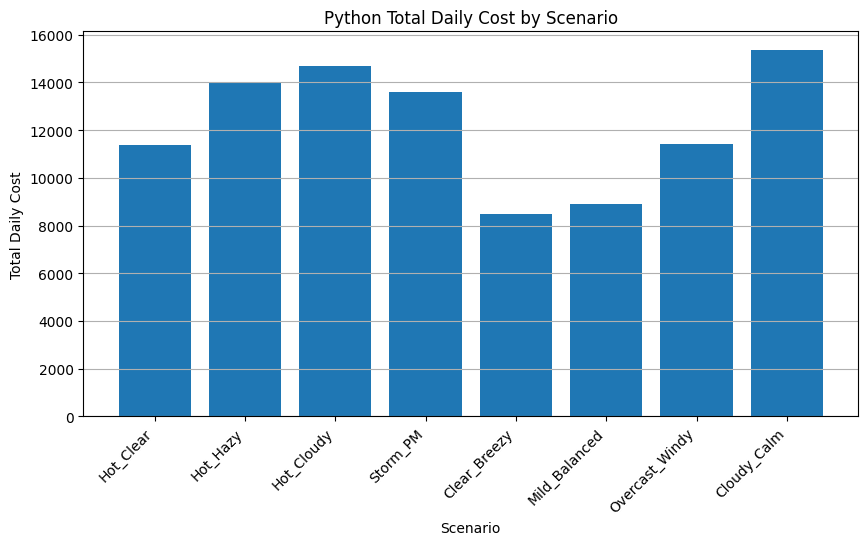

In [ ]:
# Scenario Cost Summary Plot

plt.figure(figsize=(10, 5))

plt.bar(sp_cost_summary["Scenario"], sp_cost_summary["Total_Cost"])
plt.xlabel("Scenario")
plt.ylabel("Total Daily Cost")
plt.title("Python Total Daily Cost by Scenario")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

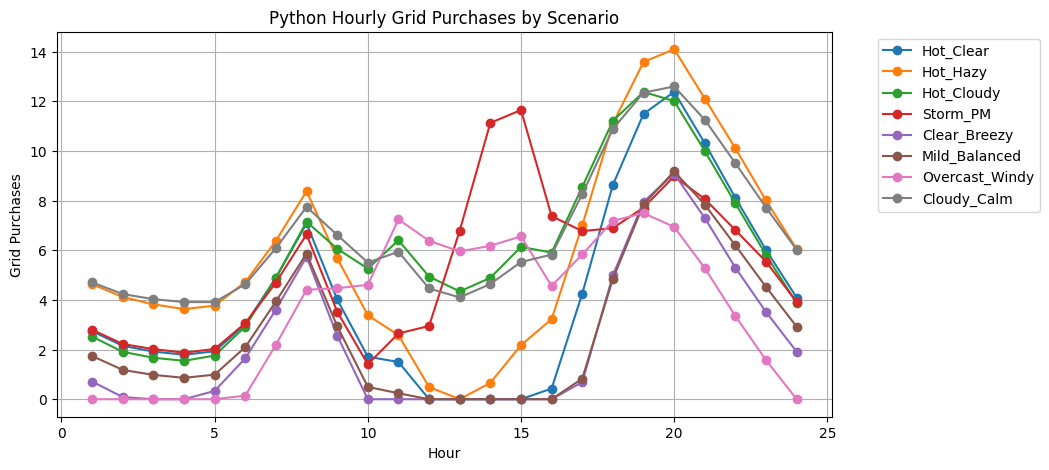

In [ ]:
# Grid Purchases by Scenario - Plot

plt.figure(figsize=(10, 5))

for w in scenarios:
    temp = sp_recourse[sp_recourse["Scenario"] == w]
    plt.plot(temp["Hour"], temp["Grid_Purchase_g"], marker="o", label=w)

plt.xlabel("Hour")
plt.ylabel("Grid Purchases")
plt.title("Python Hourly Grid Purchases by Scenario")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

##Build and Solve Deterministic Model (EV)

In [ ]:
# Structure data for EV Model
# Calculate average demand and renewable availability for the EV Model.

D_EV = {}
qS_EV = {}
qW_EV = {}

for t in T:
    D_EV[t] = sum(prob[w] * D[(t, w)] for w in scenarios)
    qS_EV[t] = sum(prob[w] * qS[(t, w)] for w in scenarios)
    qW_EV[t] = sum(prob[w] * qW[(t, w)] for w in scenarios)

print("Expected value data created.")

# Build EV Model
# Initialize and load sets and parameters

ev = pyo.ConcreteModel()

ev.T = pyo.Set(initialize=T)

ev.D = pyo.Param(ev.T, initialize=D_EV)
ev.qS = pyo.Param(ev.T, initialize=qS_EV)
ev.qW = pyo.Param(ev.T, initialize=qW_EV)

ev.cS = pyo.Param(ev.T, initialize=solar_cost)
ev.cW = pyo.Param(ev.T, initialize=wind_cost)
ev.pG = pyo.Param(ev.T, initialize=grid_price)
ev.pE = pyo.Param(ev.T, initialize=export_price)
ev.US = pyo.Param(ev.T, initialize=solar_cap)
ev.UW = pyo.Param(ev.T, initialize=wind_cap)

ev.xS = pyo.Var(ev.T, domain=pyo.NonNegativeReals)
ev.xW = pyo.Var(ev.T, domain=pyo.NonNegativeReals)
ev.g = pyo.Var(ev.T, domain=pyo.NonNegativeReals)
ev.e = pyo.Var(ev.T, domain=pyo.NonNegativeReals)

# EV Objective Function

def ev_objective_rule(ev):
    return sum(
        ev.cS[t] * ev.xS[t]
        + ev.cW[t] * ev.xW[t]
        + ev.pG[t] * ev.g[t]
        - ev.pE[t] * ev.e[t]
        for t in ev.T
    )

ev.objective = pyo.Objective(rule=ev_objective_rule, sense=pyo.minimize)

# EV Energy Balance Constraints

def ev_balance_rule(ev, t):
    return ev.qS[t] * ev.xS[t] + ev.qW[t] * ev.xW[t] + ev.g[t] - ev.e[t] == ev.D[t]

ev.energy_balance = pyo.Constraint(ev.T, rule=ev_balance_rule)

ev.solar_capacity = pyo.Constraint(ev.T, rule=lambda ev, t: ev.xS[t] <= ev.US[t])
ev.wind_capacity = pyo.Constraint(ev.T, rule=lambda ev, t: ev.xW[t] <= ev.UW[t])

# EV Model Solver
ev_results = solver.solve(ev)

print("EV Objective:", pyo.value(ev.objective))


Expected value data created.
EV Objective: 11518.340957864326


In [ ]:
#EV Committments
ev_commitments = pd.DataFrame({
    "Hour": T,
    "EV_Solar_xS": [pyo.value(ev.xS[t]) for t in T],
    "EV_Wind_xW": [pyo.value(ev.xW[t]) for t in T]
})

display(ev_commitments)

,Hour,EV_Solar_xS,EV_Wind_xW
0,1,0.0,14.000000
1,2,0.0,14.000000
2,3,0.0,14.000000
3,4,0.0,14.000000
4,5,0.0,14.000000
5,6,0.0,14.000000
6,7,0.0,14.000000
7,8,0.0,14.000000
8,9,20.0,14.000000
9,10,20.0,14.000000


## Benchmark Models and Metrics

Expected Value Model (EEV)

In [ ]:
# Expected Value Model (EEV)
# Evaluates the EV decisions across all stochastic scenarios

ev_xS = {t: pyo.value(ev.xS[t]) for t in T}
ev_xW = {t: pyo.value(ev.xW[t]) for t in T}

eev = pyo.ConcreteModel()

eev.T = pyo.Set(initialize=T)
eev.Omega = pyo.Set(initialize=scenarios)

eev.g = pyo.Var(eev.T, eev.Omega, domain=pyo.NonNegativeReals)
eev.e = pyo.Var(eev.T, eev.Omega, domain=pyo.NonNegativeReals)

def eev_objective_rule(eev):
    first_stage = sum(
        solar_cost[t] * ev_xS[t] + wind_cost[t] * ev_xW[t]
        for t in T
    )

    expected_recourse = sum(
        prob[w] * sum(
            grid_price[t] * eev.g[t, w] - export_price[t] * eev.e[t, w]
            for t in T
        )
        for w in scenarios
    )

    return first_stage + expected_recourse

eev.objective = pyo.Objective(rule=eev_objective_rule, sense=pyo.minimize)

def eev_balance_rule(eev, t, w):
    return (
        qS[(t, w)] * ev_xS[t]
        + qW[(t, w)] * ev_xW[t]
        + eev.g[t, w]
        - eev.e[t, w]
        == D[(t, w)]
    )

eev.energy_balance = pyo.Constraint(eev.T, eev.Omega, rule=eev_balance_rule)

solver.solve(eev)

z_EEV = pyo.value(eev.objective)

print("EEV Objective:", z_EEV)

EEV Objective: 12131.192394709293


Wait-and-See Model

In [ ]:
# Wait-and-See Model
# Solves each scenario separately as if the weather were known in advance

ws_results_list = []

for w in scenarios:
    ws = pyo.ConcreteModel()

    ws.T = pyo.Set(initialize=T)

    ws.xS = pyo.Var(ws.T, domain=pyo.NonNegativeReals)
    ws.xW = pyo.Var(ws.T, domain=pyo.NonNegativeReals)
    ws.g = pyo.Var(ws.T, domain=pyo.NonNegativeReals)
    ws.e = pyo.Var(ws.T, domain=pyo.NonNegativeReals)

    def ws_objective_rule(ws):
        return sum(
            solar_cost[t] * ws.xS[t]
            + wind_cost[t] * ws.xW[t]
            + grid_price[t] * ws.g[t]
            - export_price[t] * ws.e[t]
            for t in ws.T
        )

    ws.objective = pyo.Objective(rule=ws_objective_rule, sense=pyo.minimize)

    def ws_balance_rule(ws, t):
        return (
            qS[(t, w)] * ws.xS[t]
            + qW[(t, w)] * ws.xW[t]
            + ws.g[t]
            - ws.e[t]
            == D[(t, w)]
        )

    ws.energy_balance = pyo.Constraint(ws.T, rule=ws_balance_rule)
    ws.solar_capacity = pyo.Constraint(ws.T, rule=lambda ws, t: ws.xS[t] <= solar_cap[t])
    ws.wind_capacity = pyo.Constraint(ws.T, rule=lambda ws, t: ws.xW[t] <= wind_cap[t])

    solver.solve(ws)

    ws_cost = pyo.value(ws.objective)

    ws_results_list.append({
        "Scenario": w,
        "Probability": prob[w],
        "WS_Cost": ws_cost,
        "Weighted_WS_Cost": prob[w] * ws_cost
    })

ws_summary = pd.DataFrame(ws_results_list)

z_WS = ws_summary["Weighted_WS_Cost"].sum()

display(ws_summary)

print("Wait-and-See Expected Cost:", z_WS)

,Scenario,Probability,WS_Cost,Weighted_WS_Cost
0,Hot_Clear,0.16,11371.945699,1819.511312
1,Hot_Hazy,0.14,13793.752595,1931.125363
2,Hot_Cloudy,0.12,14446.516000,1733.581920
3,Storm_PM,0.10,13203.279716,1320.327972
4,Clear_Breezy,0.14,8336.038021,1167.045323
5,Mild_Balanced,0.14,8753.173002,1225.444220
6,Overcast_Windy,0.10,10833.106198,1083.310620
7,Cloudy_Calm,0.10,14960.128000,1496.012800


Wait-and-See Expected Cost: 11776.359529728878


EVPI and VSS

In [ ]:
# EVPI and VSS
# Computes the value of perfect information and the value of using the
# stochastic solution.

z_SP = pyo.value(m.objective)
z_EV = pyo.value(ev.objective)

EVPI = z_SP - z_WS
VSS = z_EEV - z_SP

benchmark_summary = pd.DataFrame({
    "Metric": ["SP", "EV", "EEV", "WS", "EVPI", "VSS"],
    "Value": [z_SP, z_EV, z_EEV, z_WS, EVPI, VSS]
})

display(benchmark_summary)

,Metric,Value
0,SP,12022.522403
1,EV,11518.340958
2,EEV,12131.192395
3,WS,11776.359530
4,EVPI,246.162873
5,VSS,108.669992


SP vs EV Comparison

,Hour,Solar_xS,Wind_xW,EV_Solar_xS,EV_Wind_xW
0,1,0.0,14.000000,0.0,14.000000
1,2,0.0,14.000000,0.0,14.000000
2,3,0.0,13.723404,0.0,14.000000
3,4,0.0,13.498233,0.0,14.000000
4,5,0.0,14.000000,0.0,14.000000
5,6,0.0,14.000000,0.0,14.000000
6,7,0.0,14.000000,0.0,14.000000
7,8,0.0,14.000000,0.0,14.000000
8,9,20.0,14.000000,20.0,14.000000
9,10,20.0,13.040000,20.0,14.000000


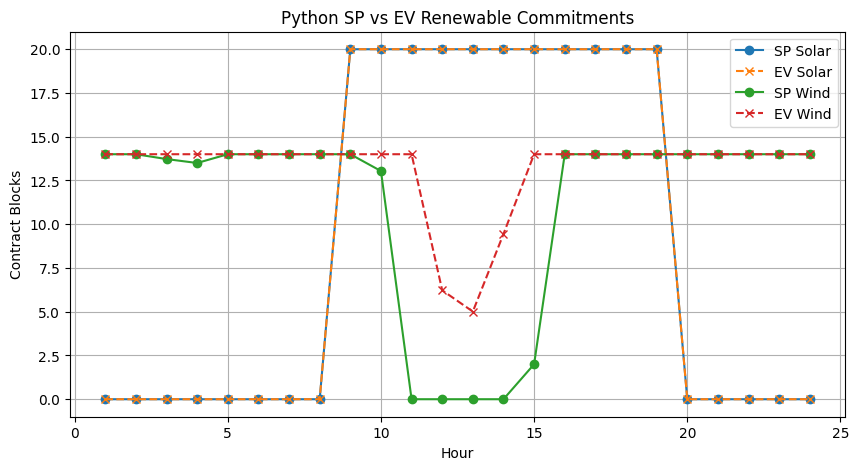

In [ ]:
# SP vs EV Comparison
# Comparison of Stochastic and Deterministic renewable commitment schedules

comparison = sp_commitments.merge(ev_commitments, on="Hour")

display(comparison)

plt.figure(figsize=(10, 5))

plt.plot(comparison["Hour"], comparison["Solar_xS"], marker="o", label="SP Solar")
plt.plot(comparison["Hour"], comparison["EV_Solar_xS"], marker="x", linestyle="--", label="EV Solar")

plt.plot(comparison["Hour"], comparison["Wind_xW"], marker="o", label="SP Wind")
plt.plot(comparison["Hour"], comparison["EV_Wind_xW"], marker="x", linestyle="--", label="EV Wind")

plt.xlabel("Hour")
plt.ylabel("Contract Blocks")
plt.title("Python SP vs EV Renewable Commitments")
plt.legend()
plt.grid(True)

plt.show()

# Build Sensitivity Model and Solve

In [ ]:
# Sensitivity: Peak Grid Price Increase
# Create modified grid pricing
grid_price_sens = grid_price.copy()

peak_hours = [16, 17, 18, 19, 20]

for t in peak_hours:
    grid_price_sens[t] = grid_price[t] * 1.20

print("Original peak grid prices:")
print({t: grid_price[t] for t in peak_hours})

print("Modified peak grid prices:")
print({t: grid_price_sens[t] for t in peak_hours})

Original peak grid prices:
{16: 98, 17: 108, 18: 116, 19: 112, 20: 98}
Modified peak grid prices:
{16: 117.6, 17: 129.6, 18: 139.2, 19: 134.4, 20: 117.6}


In [ ]:
# Build Sensitivity Model and Solve
# Re-solves the stochastic model using the modified peak-hour grid prices

sens = pyo.ConcreteModel()

sens.T = pyo.Set(initialize=T)
sens.Omega = pyo.Set(initialize=scenarios)

sens.prob = pyo.Param(sens.Omega, initialize=prob)

sens.D = pyo.Param(sens.T, sens.Omega, initialize=D)
sens.qS = pyo.Param(sens.T, sens.Omega, initialize=qS)
sens.qW = pyo.Param(sens.T, sens.Omega, initialize=qW)

sens.cS = pyo.Param(sens.T, initialize=solar_cost)
sens.cW = pyo.Param(sens.T, initialize=wind_cost)
sens.pG = pyo.Param(sens.T, initialize=grid_price_sens)
sens.pE = pyo.Param(sens.T, initialize=export_price)
sens.US = pyo.Param(sens.T, initialize=solar_cap)
sens.UW = pyo.Param(sens.T, initialize=wind_cap)

sens.xS = pyo.Var(sens.T, domain=pyo.NonNegativeReals)
sens.xW = pyo.Var(sens.T, domain=pyo.NonNegativeReals)
sens.g = pyo.Var(sens.T, sens.Omega, domain=pyo.NonNegativeReals)
sens.e = pyo.Var(sens.T, sens.Omega, domain=pyo.NonNegativeReals)

def sens_objective_rule(sens):
    first_stage_cost = sum(
        sens.cS[t] * sens.xS[t] + sens.cW[t] * sens.xW[t]
        for t in sens.T
    )

    expected_recourse_cost = sum(
        sens.prob[w] * sum(
            sens.pG[t] * sens.g[t, w] - sens.pE[t] * sens.e[t, w]
            for t in sens.T
        )
        for w in sens.Omega
    )

    return first_stage_cost + expected_recourse_cost

sens.objective = pyo.Objective(rule=sens_objective_rule, sense=pyo.minimize)

def sens_balance_rule(sens, t, w):
   return (
        sens.qS[t, w] * sens.xS[t]
        + sens.qW[t, w] * sens.xW[t]
        + sens.g[t, w]
        - sens.e[t, w]
        == sens.D[t, w]
    )

sens.energy_balance = pyo.Constraint(sens.T, sens.Omega, rule=sens_balance_rule)
sens.solar_capacity = pyo.Constraint(sens.T, rule=lambda sens, t: sens.xS[t] <= sens.US[t])
sens.wind_capacity = pyo.Constraint(sens.T, rule=lambda sens, t: sens.xW[t] <= sens.UW[t])

sens_results = solver.solve(sens)

print("Sensitivity Objective:", pyo.value(sens.objective))

Sensitivity Objective: 12818.309698960378


In [ ]:
# Sensitivity Comparicon
# Comparison of the original stochastic solution with the sensitivity results

sens_commitments = pd.DataFrame({
    "Hour": T,
    "Sensitivity_Solar_xS": [pyo.value(sens.xS[t]) for t in T],
    "Sensitivity_Wind_xW": [pyo.value(sens.xW[t]) for t in T]
})

sensitivity_comparison = sp_commitments.merge(sens_commitments, on="Hour")

display(sensitivity_comparison)

print("Original SP Objective:", z_SP)
print("Sensitivity Objective:", pyo.value(sens.objective))
print("Change in Objective:", pyo.value(sens.objective) - z_SP)

,Hour,Solar_xS,Wind_xW,Sensitivity_Solar_xS,Sensitivity_Wind_xW
0,1,0.0,14.000000,0.0,14.000000
1,2,0.0,14.000000,0.0,14.000000
2,3,0.0,13.723404,0.0,13.723404
3,4,0.0,13.498233,0.0,13.498233
4,5,0.0,14.000000,0.0,14.000000
5,6,0.0,14.000000,0.0,14.000000
6,7,0.0,14.000000,0.0,14.000000
7,8,0.0,14.000000,0.0,14.000000
8,9,20.0,14.000000,20.0,14.000000
9,10,20.0,13.040000,20.0,13.040000


Original SP Objective: 12022.522402960378
Sensitivity Objective: 12818.309698960378
Change in Objective: 795.7872960000004


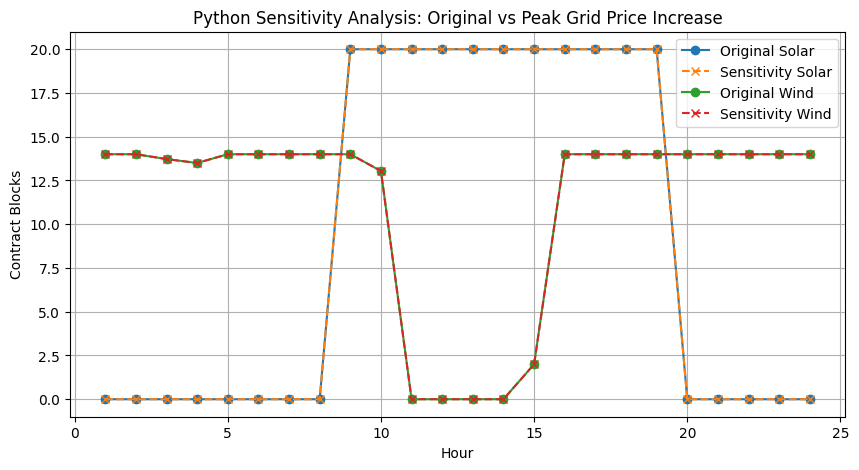

In [ ]:
# Sensitivity Plot
# Visualizes how renewable commitments change under higher peak grid prices

plt.figure(figsize=(10, 5))

plt.plot(sensitivity_comparison["Hour"], sensitivity_comparison["Solar_xS"], marker="o", label="Original Solar")
plt.plot(sensitivity_comparison["Hour"], sensitivity_comparison["Sensitivity_Solar_xS"], marker="x", linestyle="--", label="Sensitivity Solar")

plt.plot(sensitivity_comparison["Hour"], sensitivity_comparison["Wind_xW"], marker="o", label="Original Wind")
plt.plot(sensitivity_comparison["Hour"], sensitivity_comparison["Sensitivity_Wind_xW"], marker="x", linestyle="--", label="Sensitivity Wind")

plt.xlabel("Hour")
plt.ylabel("Contract Blocks")
plt.title("Python Sensitivity Analysis: Original vs Peak Grid Price Increase")
plt.legend()
plt.grid(True)

plt.show()

notes/trial code: